In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris (2).csv to iris (2).csv


In [4]:
import pandas as pd

file_path = '/content/iris (2).csv'
df = pd.read_csv(file_path)

print(f"Data loaded from: {file_path}")
display(df.head())
df.info()

Data loaded from: /content/iris (2).csv


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) from the target (y - 'species')
X = df.drop('species', axis=1) # Features for clustering
y = df['species'] # Original species labels, useful for comparison later

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First 5 rows of scaled features (X_scaled):\n", X_scaled[:5])

First 5 rows of scaled features (X_scaled):
 [[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]]


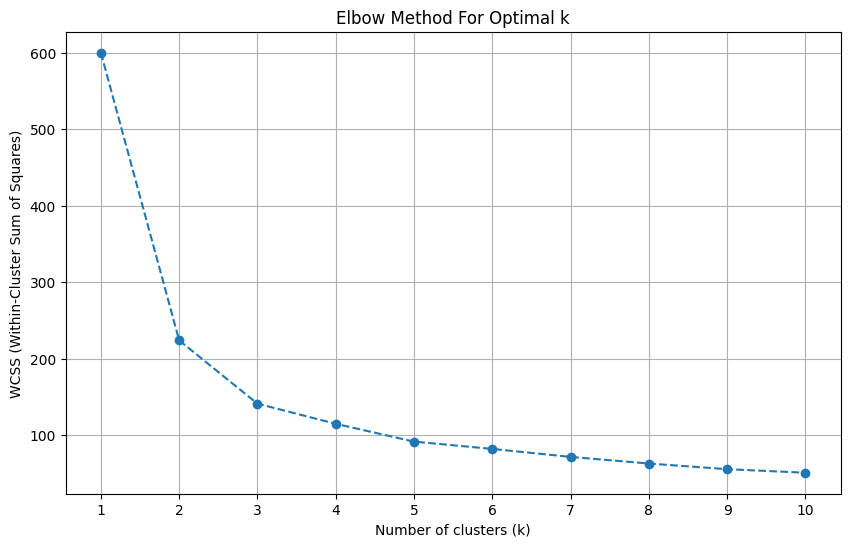

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = [] # List to store WCSS for each k

# Try k from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS value

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

First 5 rows of the DataFrame with assigned clusters:
    sepal_length  sepal_width  petal_length  petal_width      species  Cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        1
2           4.7          3.2           1.3          0.2  Iris-setosa        1
3           4.6          3.1           1.5          0.2  Iris-setosa        1
4           5.0          3.6           1.4          0.2  Iris-setosa        1


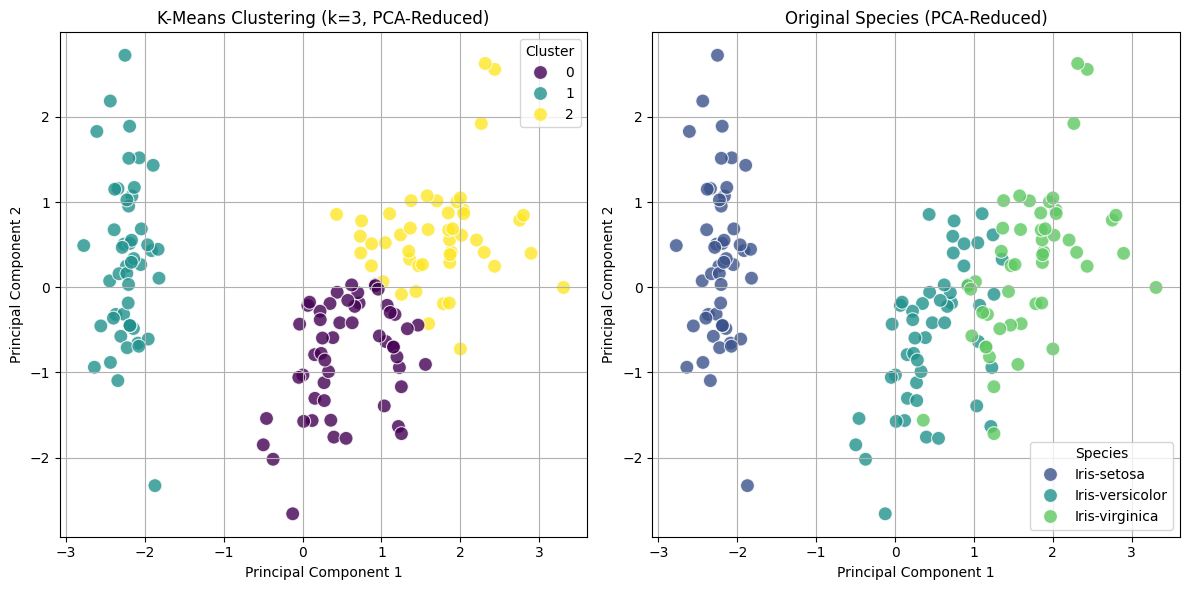

In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply K-Means with the chosen number of clusters (k=3 for Iris)
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels to a copy of the original dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = clusters

print("First 5 rows of the DataFrame with assigned clusters:\n", df_clustered.head())

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results and add cluster labels and original species
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Cluster'] = clusters
df_pca['Species'] = df['species'] # Include original species for comparison

# Plot the K-Means clusters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette='viridis',
    data=df_pca,
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title('K-Means Clustering (k=3, PCA-Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Plot the original species for comparison
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Species',
    palette='viridis',
    data=df_pca,
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title('Original Species (PCA-Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.tight_layout()
plt.show()